# BEM with surface integral equation (SIE) method (Lamia v2.3) 

LAMIA = Light Absorption and Mie-scattering Interaction Algorithm 

Clean Python version from https://github.com/freshleaf4398/Surface-Integral-Equation/tree/main. SALOME med mesh files operations are added, instead of COMSOL mphtxt/mat mesh files. Finding the farfield distribution, T-matrix, multipole decomposition, and cross sections from a homogeneous nanoparticle systems. 

The radius of the farfield should not be very high, the code can mess the ext and abs cross section.

Latest features: 
* Nearfield distributions with masks 
* One cell runs

Far-field loop - wavelength:   0%|          | 0/251 [00:00<?, ?it/s]

T-matrix calculation - wavelength: 100%|███████████████████████████████████████████| 251/251 [00:00<00:00, 14315.42it/s]


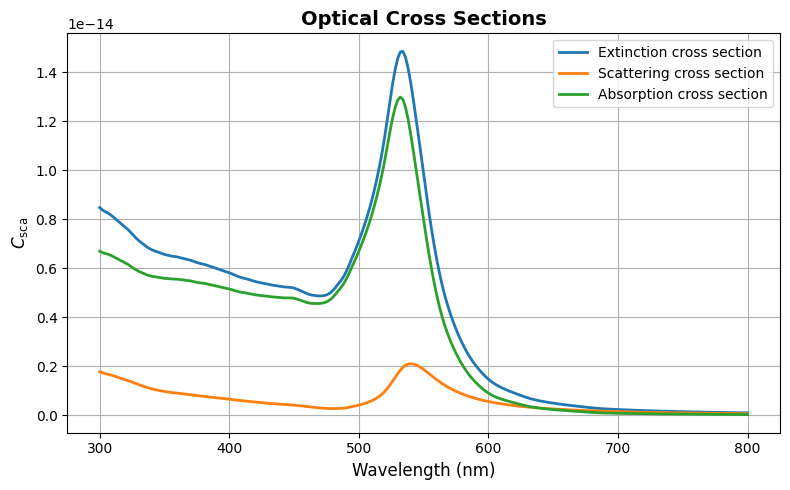

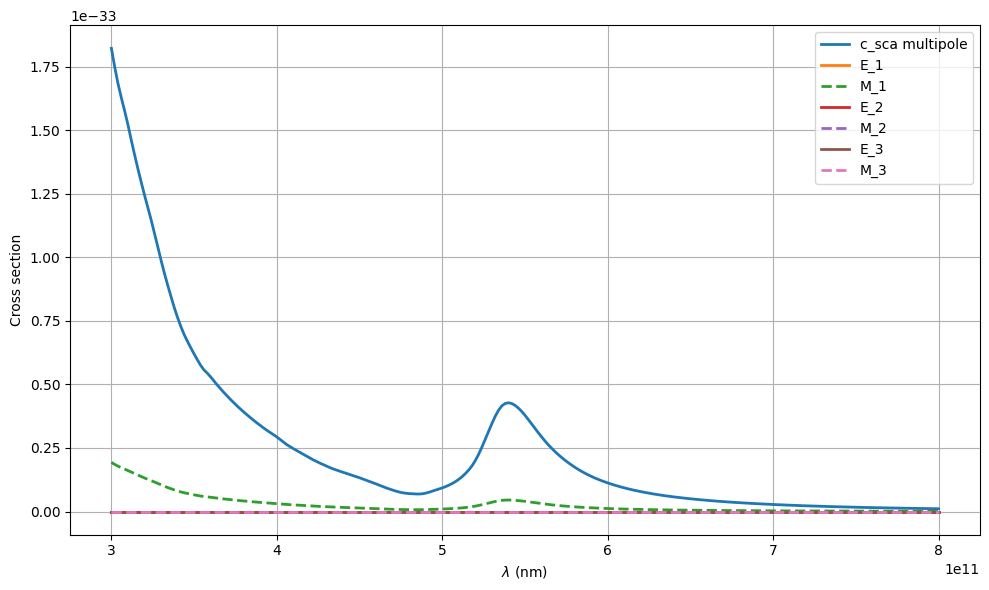

In [2]:
import meshio
import numpy as np
import pandas as pd
import scipy.io
from numpy.linalg import norm
from scipy.io import savemat, loadmat
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
from math import factorial
from shapely.geometry import Point, Polygon
from mpl_toolkits.mplot3d import Axes3D

from triangulation import triangulation
from special_integrals import special_integrals
from element_integrals import element_integrals
from element_integrals_2d import element_integrals_2d
from compute_farfields import compute_farfields
from compute_nearfields import compute_nearfields
from compute_nearfields_full import compute_nearfields_full
from compute_cross_sections import compute_cross_sections
from multipole_decomp_tmat import multipole_decomp_tmat

# Materials
J_C_weaver_Au = scipy.io.loadmat("J_C_weaver_Au.mat")
eps_bg = 1.0  # Background: vacuum

# Input wavelength here

# lambda_interp = np.array((552,619)) # USE THIS FOR SINGLE WL -> FIELD DISTRIBUTIONS, JUST CHANGE THE FIRST WL NOT THE SECOND
lambda_interp = np.arange(300, 801, 2).reshape(-1, 1) # USE THIS FOR ARRAY WL -> SPECTRUMS
eV_interp = 1240.0 / lambda_interp  # Convert nm to eV

x1 = J_C_weaver_Au["eV"].flatten()
y1_re = J_C_weaver_Au["n"].flatten()
y1_im = J_C_weaver_Au["k"].flatten()


# === Input the scatterer and the farfield sphere meshes file here (SALOME med) ===
# 3D scatterer mesh
mesh = meshio.read('cube_x50.med')
p = mesh.points*1e-9
t = mesh.cells_dict["triangle"]
p = p.T

# 3D farfield mesh
mesh_ff = meshio.read('sphere_200nm.med') # 200 nm sphere, dont go very far, go far when the object is large enough
p_ff = mesh_ff.points*1e-9
t_ff = mesh_ff.cells_dict["triangle"]
p_ff = p_ff.T

# 2D scatterer mesh
mesh_2d = meshio.read('cone_x_r30_h50_2d.med')
p_2d = mesh_2d.points*1e-9
p_2d = p_2d.T

# 2D grid points
x = np.linspace(-20, 20, 60)*1e-9 #modify the size of the mesh grids here
y = np.linspace(-40, 40, 60)*1e-9 #modify the size of the mesh grids here
X, Y = np.meshgrid(x, y)
# #####################################################################################################
# # MASKS: circle vertices
# center = (0, 0)
# radius = 50.0*1e-9
# num_circle_points = 1000
# theta = np.linspace(0, 2*np.pi, num_circle_points)
# circle_points = [(center[0] + radius*np.cos(t), center[1] + radius*np.sin(t)) for t in theta]
# cs2d = Polygon(circle_points)
# mask = np.array([[cs2d.contains(Point(xy)) for xy in zip(row_x, row_y)]
#                  for row_x, row_y in zip(X, Y)], dtype=bool)

# mask_x = center[0] + radius * np.cos(theta)
# mask_y = center[1] + radius * np.sin(theta)

######################################################################################################

# Define triangle vertices (example: equilateral centered at origin)
triangle_vertices = [
    (0, -25*1e-9),          
    (-15*1e-9, 25*1e-9), 
    (15*1e-9, 25*1e-9)    
]

# Create the triangle polygon
tri2d = Polygon(triangle_vertices)

# Build mask: True for points inside the triangle
mask = np.array([[tri2d.contains(Point(xy)) for xy in zip(row_x, row_y)]
                 for row_x, row_y in zip(X, Y)], dtype=bool)

# Optional: for plotting/reference
mask_x, mask_y = zip(*triangle_vertices)
mask_x = np.append(mask_x, mask_x[0])  # close the triangle
mask_y = np.append(mask_y, mask_y[0])

######################################################################################################

geo = triangulation(p, t, p_ff, t_ff)
spec_int = special_integrals(geo)
elem_int = element_integrals(geo)
far = compute_farfields(lambda_interp, x1, y1_re, y1_im, eps_bg, geo, spec_int, elem_int)

######################################################################################################
# CROSS SECTIONS, DECOMP, and T-MATRIX (USE FULL WAVELENGTHS)
# BLOCK COMMENT THIS IF YOU DO MONOCHROMATICS!!!

cs = compute_cross_sections(lambda_interp, eps_bg, geo["luas_ff"], geo["faceNorm_ff"], 
                            far["E_farfield_sca"], far["H_farfield_sca"],
                            far["E_farfield_inc"], far["H_farfield_inc"], 
                            far["E_farfield_total"], far["H_farfield_total"])
N_multipole = 3
decomp_Tmat = multipole_decomp_tmat(eps_bg, lambda_interp, N_multipole, geo['titik_tengah_ff'], 
                                    geo['faceNorm_ff'], geo['luas_ff'],
                                    far['E_farfield_sca'], far['H_farfield_sca'], far['E_farfield_inc'])
######################################################################################################

# NEARFIELDS (CAUTION: USE ONLY 2 WAVELENGTH, LAMBDA_INTERP = [WAVELENGTH DUMMYWAVELENGTH]!!!)
# BLOCK COMMENT THIS IF YOU DO SPECTRUMS!!!

# near = compute_nearfields_full(lambda_interp, x1, y1_re, y1_im, eps_bg, geo, X, Y, far, mask, mask_x, mask_y)